In [17]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import distance_transform_edt


In [3]:
def computeH(im1_pts, im2_pts): #using least squares bec more than 4 correspondences produce an overdetermined system
    assert im1_pts.shape == im2_pts.shape
    N = im1_pts.shape[0]
    A = []

    for i in range(N):
        x, y = im1_pts[i, 0], im1_pts[i, 1]
        x_p, y_p = im2_pts[i, 0], im2_pts[i, 1]
        A.append([-x, -y, -1, 0, 0, 0, x*x_p, y*x_p, x_p])
        A.append([0, 0, 0, -x, -y, -1, x*y_p, y*y_p, y_p]) #system of equations

    A = np.asarray(A)
    # Solve Ah = 0 homogeneous system
    U, S, Vt = np.linalg.svd(A)
    H = Vt[-1].reshape(3, 3)
    H /= H[2, 2] 
    return H

In [4]:
def warp_bound(im,H):
    h, w = im.shape[:2]
    corners = np.array([[0,0,1], [w,0,1], [0,h,1], [w,h,1]]).T  # 3x4
    warped_corners = H @ corners
    warped_corners /= warped_corners[2,:]
    min_x, max_x = warped_corners[0].min(), warped_corners[0].max()
    min_y, max_y = warped_corners[1].min(), warped_corners[1].max()
    return min_x, max_x, min_y, max_y

In [5]:
# using bilinear interpolation warping method
def warpImageBilinear(im, H):
    h, w = im.shape[:2]
    Hinv = np.linalg.inv(H)

    min_x, max_x, min_y, max_y = warp_bound(im, H)
    out_w, out_h = int(np.ceil(max_x - min_x)), int(np.ceil(max_y - min_y))
    imwarped = np.zeros((out_h, out_w, 3), dtype=np.uint8)

    for y_out in range(out_h):
        for x_out in range(out_w):
            target = np.array([x_out + min_x, y_out + min_y, 1])
            src = Hinv @ target
            src /= src[2]

            x_src, y_src = src[0], src[1]
            if 0 <= x_src < w - 1 and 0 <= y_src < h - 1:
                x0, y0 = int(np.floor(x_src)), int(np.floor(y_src))
                dx, dy = x_src - x0, y_src - y0

                # nearest 4 neighbouring pixel
                top_left = im[y0, x0]
                top_right = im[y0, x0 + 1]
                bottom_left = im[y0 + 1, x0]
                bottom_right = im[y0 + 1, x0 + 1]

                # taking thier weighted average
                top = (1 - dx) * top_left + dx * top_right
                bottom = (1 - dx) * bottom_left + dx * bottom_right
                value = (1 - dy) * top + dy * bottom

                imwarped[y_out, x_out] = np.clip(value, 0, 255)
    return imwarped


In [30]:
im1 = cv2.cvtColor(cv2.imread("media/houseleft.jpg"), cv2.COLOR_BGR2RGB)
im2 = cv2.cvtColor(cv2.imread("media/houseright.jpg"), cv2.COLOR_BGR2RGB)

In [31]:
scale = 1500 / im1.shape[1]
new_h1 = int(im1.shape[0] * scale)
new_h2 = int(im2.shape[0] * scale)
im1_small = cv2.resize(im1, (1500, new_h1))
im2_small = cv2.resize(im2, (1500, new_h2))
print("Resized shapes:", im1_small.shape, im2_small.shape)
print("Scale factor:", scale)

Resized shapes: (1999, 1500, 3) (1999, 1500, 3)
Scale factor: 0.35014005602240894


In [32]:
im1_pts = np.array([[3461,724],[3725,285],[3978,363],[2657,3613],[2629,3743],[3602,3509],[3757,3546],[4000,4918]])
im2_pts = np.array([[2131,904],[2365,543],[2581,658],[1349,3670],[1316,3807],[2236,3512],[2368,3542],[2568,4802]])

In [33]:
# Scale correspondences down to match downscaled images
im1_pts_scaled = im1_pts * scale
im2_pts_scaled = im2_pts * scale

print("First im1 point before:", im1_pts[0], "after scaling:", im1_pts_scaled[0])


First im1 point before: [3461  724] after scaling: [1211.83473389  253.50140056]


In [ ]:
H = computeH(im1_pts_scaled, im2_pts_scaled)
print("Homography matrix:\n", H) #downscaled H

Homography matrix:
 [[ 1.38084749e+00 -2.79472404e-02 -6.68338255e+02]
 [ 2.80865886e-01  1.22648885e+00 -2.28665126e+02]
 [ 2.80584845e-04 -2.23914193e-05  1.00000000e+00]]


In [35]:
im1_warped = warpImageBilinear(im1_small, H)
print("Warped image shape:", im1_warped.shape)

Warped image shape: (2556, 1746, 3)


In [36]:
min_x, max_x, min_y, max_y = warp_bound(im1_small, H)
print(f"Warped bounds: x=[{min_x:.1f}, {max_x:.1f}], y=[{min_y:.1f}, {max_y:.1f}]")

Warped bounds: x=[-758.1, 987.4], y=[-228.7, 2327.3]


In [ ]:
# Create translation matrix , shift everything, since some coords are negative
offset_x = int(np.floor(min(0, min_x)))
offset_y = int(np.floor(min(0, min_y)))
T = np.array([[1, 0, -offset_x],[0, 1, -offset_y],[0, 0, 1]])

In [38]:
canvas_w = int(np.ceil(max(max_x, im2_small.shape[1]) - min(0, min_x)))
canvas_h = int(np.ceil(max(max_y, im2_small.shape[0]) - min(0, min_y)))
print(f"Canvas size: {canvas_w} x {canvas_h}")

# creating the mosaic canvas
mosaic = np.zeros((canvas_h, canvas_w, 3), dtype=np.float32)
mask1 = np.zeros((canvas_h, canvas_w), dtype=np.float32)
mask2 = np.zeros((canvas_h, canvas_w), dtype=np.float32)

Canvas size: 2259 x 2556


In [39]:
#goal: im1 warped onto unwarped im2's projection
# Place im2 (unwarped) on the canvas
y_start = -offset_y
x_start = -offset_x
y_end = y_start + im2_small.shape[0]
x_end = x_start + im2_small.shape[1]
mosaic[y_start:y_end, x_start:x_end] = im2_small.astype(np.float32)
mask2[y_start:y_end, x_start:x_end] = 1.0

# Warp im1 with the translation offset
H_translated = T @ H
im1_warped_full = warpImageBilinear(im1_small, H_translated)

# Place warped im1 on canvas with mask
for y in range(im1_warped_full.shape[0]):
    for x in range(im1_warped_full.shape[1]):
        if np.any(im1_warped_full[y, x] > 0):
            mask1[y, x] = 1.0

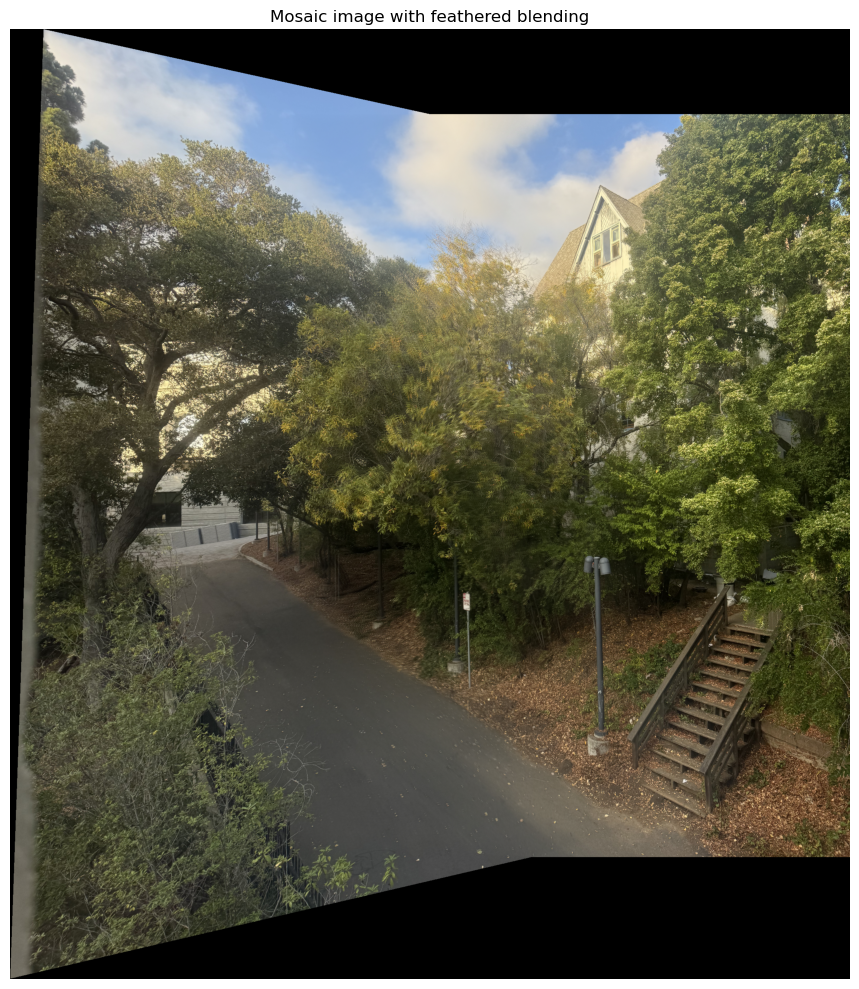

Panorama saved as 'panorama_result.jpg'


In [40]:
#weight averaging feathering effect
dist1 = distance_transform_edt(mask1)
dist2 = distance_transform_edt(mask2)

# Normalise distances to create smooth weights
weight1 = dist1 / (dist1 + dist2 + 1e-10)
weight2 = dist2 / (dist1 + dist2 + 1e-10)

#weighted bledning
overlap = (mask1 > 0) & (mask2 > 0)
for y in range(canvas_h):
    for x in range(canvas_w):
        if y < im1_warped_full.shape[0] and x < im1_warped_full.shape[1]:
            if overlap[y, x]:
                # Weighted average in overlap region
                mosaic[y, x] = (weight1[y, x] * im1_warped_full[y, x] + 
                               weight2[y, x] * mosaic[y, x])
            elif mask1[y, x] > 0:
                # Only im1 visible
                mosaic[y, x] = im1_warped_full[y, x]
mosaic = np.clip(mosaic, 0, 255).astype(np.uint8)

plt.figure(figsize=(20, 10))
plt.imshow(mosaic)
plt.axis('off')
plt.title('Mosaic image with feathered blending')
plt.tight_layout()
plt.show()

# Save result
cv2.imwrite('panorama_result.jpg', cv2.cvtColor(mosaic, cv2.COLOR_RGB2BGR))
print("Panorama saved as 'panorama_result.jpg'")